# Some Signal Review

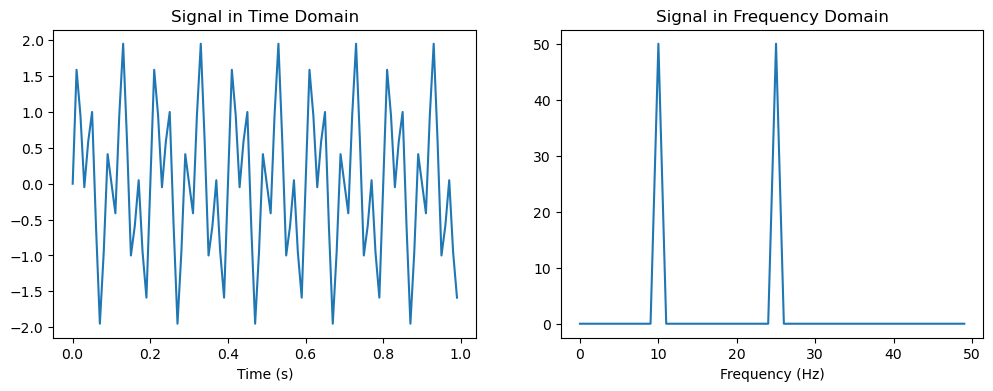

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a signal made of two frequencies: 10 Hz and 25 Hz
sfreq = 100  # sampling rate
t = np.arange(0, 1, 1/sfreq)  # 1 second

signal = np.sin(2 * np.pi * 10 * t) + np.sin(2 * np.pi * 25 * t)

# Apply Fourier transform
fft_result = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(t), 1/sfreq)
power = np.abs(fft_result)

# Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(t, signal)
plt.title('Signal in Time Domain')
plt.xlabel('Time (s)')

plt.subplot(1, 2, 2)
plt.plot(frequencies[:len(frequencies)//2], 
         power[:len(power)//2])
plt.title('Signal in Frequency Domain')
plt.xlabel('Frequency (Hz)')
plt.show()
# You'll see two clear spikes at 10 Hz and 25 Hz

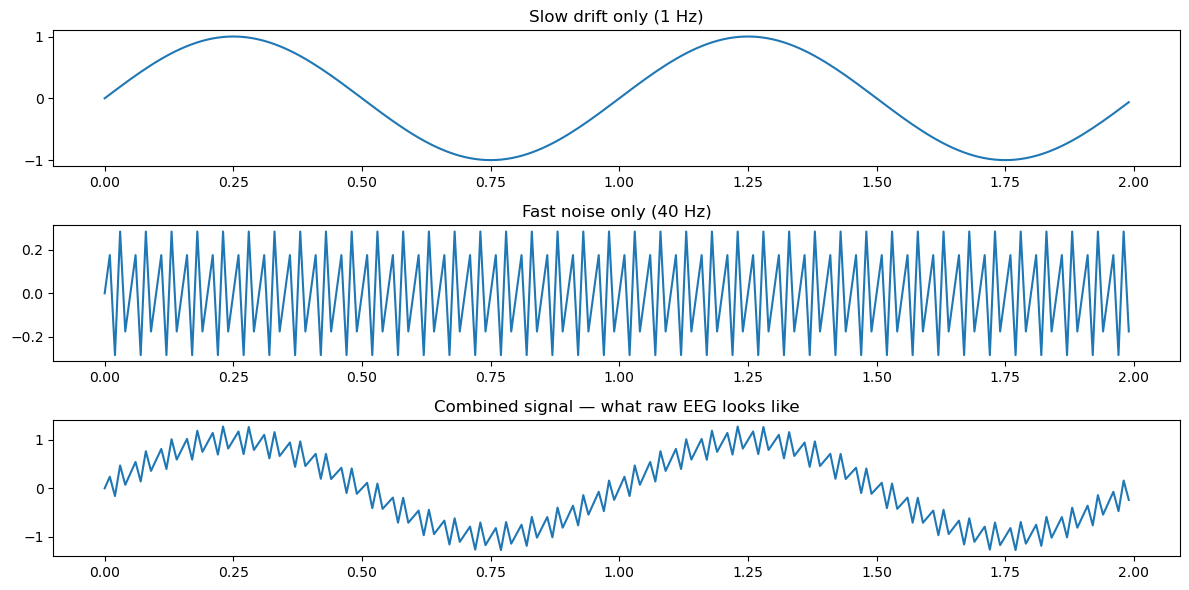

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sfreq = 100
t = np.arange(0, 2, 1/sfreq)

# Signal with both slow drift (1 Hz) and fast noise (40 Hz)
slow_drift = np.sin(2 * np.pi * 1 * t)
fast_noise = 0.3 * np.sin(2 * np.pi * 40 * t)
combined = slow_drift + fast_noise

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(t, slow_drift)
plt.title('Slow drift only (1 Hz)')

plt.subplot(3, 1, 2)
plt.plot(t, fast_noise)
plt.title('Fast noise only (40 Hz)')

plt.subplot(3, 1, 3)
plt.plot(t, combined)
plt.title('Combined signal — what raw EEG looks like')
plt.tight_layout()
plt.show()

In [3]:
# In MNE you can visualize the effect of different filters
# Compare broadband vs low frequency version of same epoch

import mne
import matplotlib.pyplot as plt

# Get one trial from your epochs
trial_data = epochs[0].get_data()[0]  # shape: (66, 421)
cz_idx = epochs.ch_names.index('Cz')
cz_signal = trial_data[cz_idx]
t = epochs.times

# Plot the signal at different frequency ranges
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Broadband (0.3-40 Hz) — what you have
axes[0].plot(t, cz_signal)
axes[0].set_title('Broadband EEG (0.3-40 Hz) — Cz channel, Trial 1')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].axvline(x=0, color='red', linestyle='--', label='onset')

# Low frequency only (0.3-3 Hz) — what sLDA used
from scipy.signal import butter, filtfilt

def lowpass_filter(data, cutoff, fs):
    b, a = butter(4, cutoff / (fs/2), btype='low')
    return filtfilt(b, a, data)

cz_lowpass = lowpass_filter(cz_signal, 3, 100)
axes[1].plot(t, cz_lowpass, color='orange')
axes[1].set_title('Low Frequency EEG (0.3-3 Hz) — Shows slow motor potential (MRCP)')
axes[1].set_xlabel('Time (s)')
axes[1].axvline(x=0, color='red', linestyle='--', label='onset')

# High frequency only
cz_highfreq = cz_signal - cz_lowpass
axes[2].plot(t, cz_highfreq, color='green')
axes[2].set_title('High Frequency Component (3-40 Hz) — Faster neural activity')
axes[2].set_xlabel('Time (s)')
axes[2].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

NameError: name 'epochs' is not defined

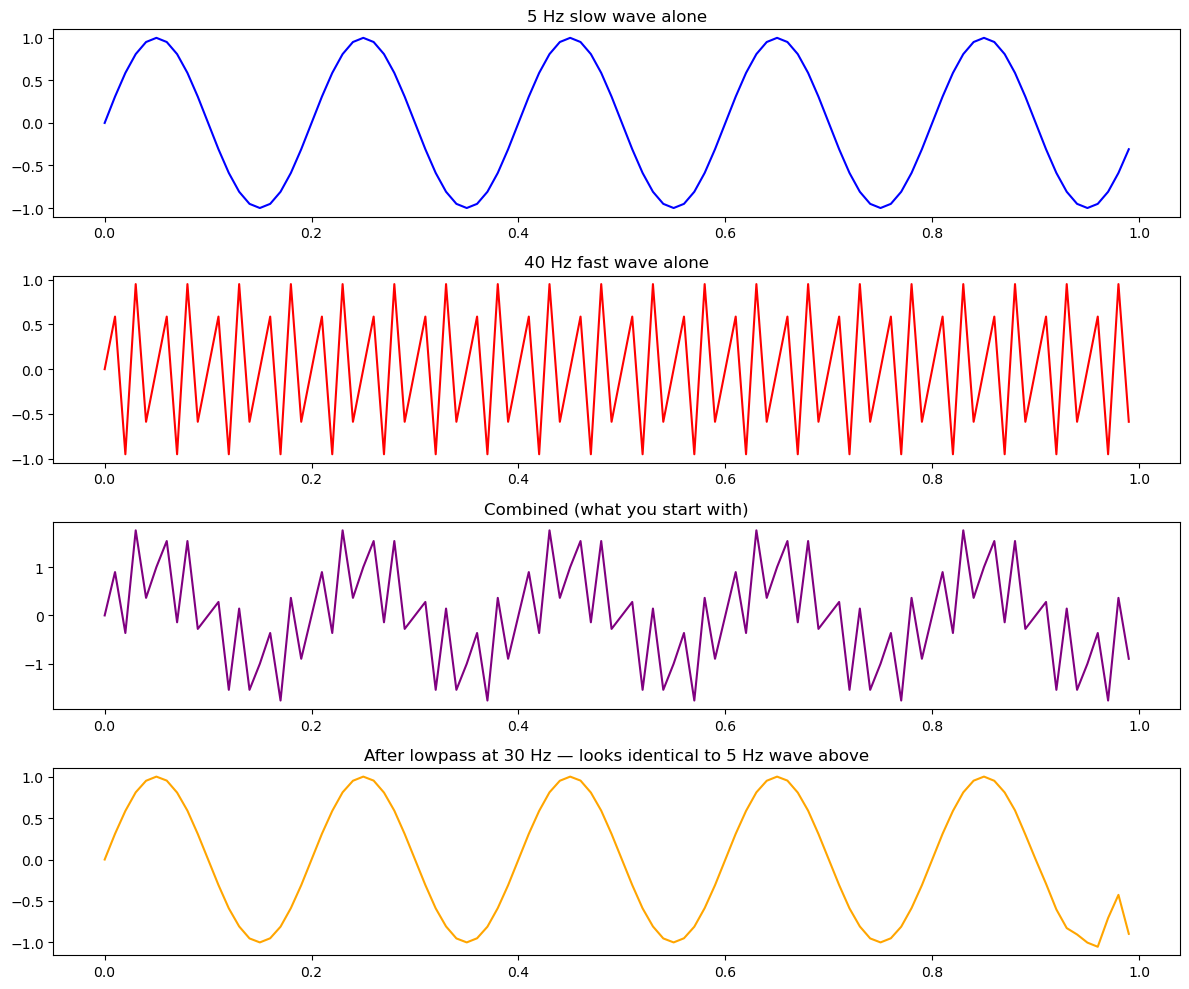

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

sfreq = 100
t = np.arange(0, 1, 1/sfreq)

slow = np.sin(2 * np.pi * 5 * t)   # 5 Hz — will survive
fast = np.sin(2 * np.pi * 40 * t)  # 40 Hz — will be removed
combined = slow + fast

def lowpass(data, cutoff, fs):
    b, a = butter(4, cutoff / (fs/2), btype='low')
    return filtfilt(b, a, data)

filtered = lowpass(combined, cutoff=30, fs=sfreq)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(t, slow, color='blue')
axes[0].set_title('5 Hz slow wave alone')

axes[1].plot(t, fast, color='red')
axes[1].set_title('40 Hz fast wave alone')

axes[2].plot(t, combined, color='purple')
axes[2].set_title('Combined (what you start with)')

axes[3].plot(t, filtered, color='orange')
axes[3].set_title('After lowpass at 30 Hz — looks identical to 5 Hz wave above')

plt.tight_layout()
plt.show()